In [10]:
import pandas as pd
import numpy as np

X = pd.read_excel("/Users/esther/PycharmProjects/ad_proteomic_clock/training_data/JPST003472.xlsx").set_index("sample_id")
meta = pd.read_excel("/Users/esther/PycharmProjects/ad_proteomic_clock/training_data/JPST003472_meta.xlsx").set_index("sample_id")

# Quality check
assert X.index.is_unique
assert meta.index.is_unique
assert set(X.index) == set(meta.index)

print("Dataset shape (samples, proteins):", X.shape)
print("\nSamples per age:")
print(meta["age"].value_counts().sort_index())

print("Total cells:", X.size)
print("Missing / NaN cells:", int(X.isna().sum().sum()))
print("Literal zeros:", int((X == 0).sum().sum()))
print("Infinite values:", int(np.isinf(X.to_numpy()).sum()))

duplicate_features = int(X.columns.duplicated().sum())
zero_variance = int((X.var(axis=0) == 0).sum())

print("\nDuplicate protein feature IDs:", duplicate_features)
print("Zero-variance proteins:", zero_variance)

print("\nPer-sample median summary:")
print(X.median(axis=1).describe())

print("\nPer-sample SD summary:")
print(X.std(axis=1).describe())


Dataset shape (samples, proteins): (45, 4122)

Samples per age:
age
3     7
5     9
8     8
14    9
20    7
26    5
Name: count, dtype: int64
Total cells: 185490
Missing / NaN cells: 0
Literal zeros: 2
Infinite values: 0

Duplicate protein feature IDs: 0
Zero-variance proteins: 0

Per-sample median summary:
count    45.000000
mean     -0.640614
std       0.044828
min      -0.744026
25%      -0.673827
50%      -0.641801
75%      -0.604032
max      -0.569841
dtype: float64

Per-sample SD summary:
count    45.000000
mean      1.681978
std       0.104099
min       1.543048
25%       1.605068
50%       1.649775
75%       1.735040
max       1.979745
dtype: float64


In [ ]:
# Copy raw data
X_raw = X.copy()
y = meta.loc[X.index, "age"].astype(float).copy()

Matplotlib is building the font cache; this may take a moment.


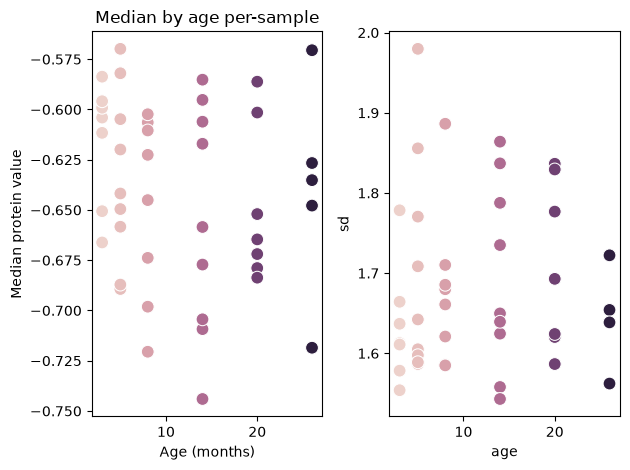

,sample,age,median,sd
39,5M_6,5.0,-0.687119,1.979745
7,8M_8,8.0,-0.720523,1.886304
14,14M_7,14.0,-0.704388,1.863992
34,5M_3,5.0,-0.658332,1.855644
13,14M_6,14.0,-0.677154,1.836888
21,20M_3,20.0,-0.671932,1.836415
25,20M_5,20.0,-0.683677,1.829284
12,14M_5,14.0,-0.709269,1.787683
33,3M_3,3.0,-0.666159,1.778385
23,20M_4,20.0,-0.678889,1.776774


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample distribution
sample_stat = pd.DataFrame({
    "sample": X.index,
    "age": meta.loc[X.index, "age"].astype(float).values,
    "median": X.median(axis=1).values,
    "sd": X.std(axis=1).values,
})

fig, axes = plt.subplots(1, 2)

sns.scatterplot(
    data = sample_stat,
    x = "age",
    y = "median",
    hue = "age",
    s = 85,
    legend = False,
    ax = axes[0]
)

axes[0].set_title("Median by age per sample")
axes[0].set_xlabel("Age (months)")
axes[0].set_ylabel("Median protein value")

sns.scatterplot(
    data=sample_stat,
    x = "age",
    y = "sd",
    hue = "age",
    s = 85,
    legend = False,
    ax = axes[1]
)

plt.tight_layout()
plt.show()

display(sample_stat.sort_values("sd", ascending=False))

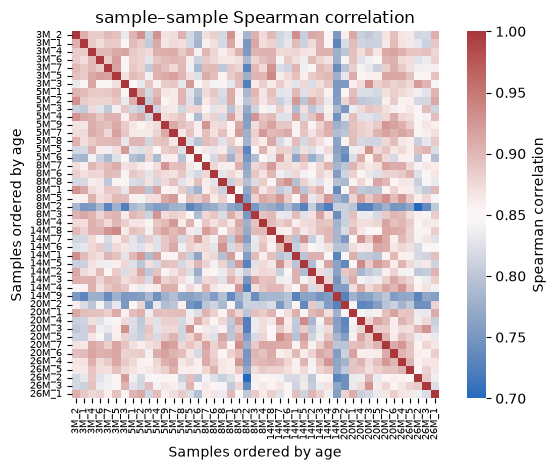

In [15]:
# Spearman correlation heatmap
sample_correlation = X.T.corr(method="spearman")

meta_aligned = meta.loc[X.index]
ordered_samples = meta_aligned.sort_values("age").index.tolist()

sample_correlation_ordered = sample_correlation.loc[
    ordered_samples,
    ordered_samples
]

plt.figure()
sns.heatmap(
    sample_correlation_ordered,
    cmap="vlag",
    vmin=0.70,
    vmax=1.00,
    center=0.85,
    square=True,
    xticklabels=ordered_samples,
    yticklabels=ordered_samples,
    cbar_kws={"label": "Spearman correlation"},
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.title("sample–sample Spearman correlation")
plt.xlabel("Samples ordered by age")
plt.ylabel("Samples ordered by age")
plt.tight_layout()
plt.show()

# Flagging 8M-2, 14M-9, 20M-2

In [20]:
flagged_samples = ["8M_2", "14M_9", "20M_2"]

# Compare with cohort
corr_no_self = sample_correlation.mask(
    np.eye(sample_correlation.shape[0], dtype=bool)
)

sample_qc = pd.DataFrame({
    "age": meta.loc[X.index, "age"].astype(float),
    "median_corr_to_others": corr_no_self.median(axis=1),
    "mean_corr_to_others": corr_no_self.mean(axis=1),
    "min_corr_to_any_other": corr_no_self.min(axis=1),
    "sample_median": X.median(axis=1),
    "sample_mean": X.mean(axis=1),
    "sample_sd": X.std(axis=1),
    "sample_iqr": X.quantile(0.75, axis=1) - X.quantile(0.25, axis=1),
})

print("Flagged samples:")
display(sample_qc.loc[flagged_samples])

print("\nLowest median correlations:")
display(sample_qc.sort_values("median_corr_to_others").head(10))

Flagged samples:


,age,median_corr_to_others,mean_corr_to_others,min_corr_to_any_other,sample_median,sample_mean,sample_sd,sample_iqr
sample_id,,,,,,,,
8M_2,8.0,0.763893,0.763491,0.699391,-0.698112,-0.655388,1.660939,1.786997
14M_9,14.0,0.763986,0.765669,0.726996,-0.744026,-0.657870,1.639351,1.783188
20M_2,20.0,0.800470,0.799265,0.726996,-0.586177,-0.507038,1.586625,1.654082



Lowest median correlations:


,age,median_corr_to_others,mean_corr_to_others,min_corr_to_any_other,sample_median,sample_mean,sample_sd,sample_iqr
sample_id,,,,,,,,
8M_2,8.0,0.763893,0.763491,0.699391,-0.698112,-0.655388,1.660939,1.786997
14M_9,14.0,0.763986,0.765669,0.726996,-0.744026,-0.657870,1.639351,1.783188
20M_2,20.0,0.800470,0.799265,0.726996,-0.586177,-0.507038,1.586625,1.654082
5M_6,5.0,0.828001,0.829186,0.736763,-0.687119,-0.795305,1.979745,2.008389
26M_2,26.0,0.839105,0.835482,0.699391,-0.718528,-0.618864,1.722106,1.928476
5M_3,5.0,0.841353,0.840297,0.749973,-0.658332,-0.679617,1.855644,1.994108
26M_3,26.0,0.850364,0.847188,0.735252,-0.647814,-0.620991,1.722248,1.924552
8M_8,8.0,0.854059,0.849270,0.787406,-0.720523,-0.734000,1.886304,1.971010
14M_2,14.0,0.855745,0.850431,0.764294,-0.658463,-0.520291,1.543048,1.740715


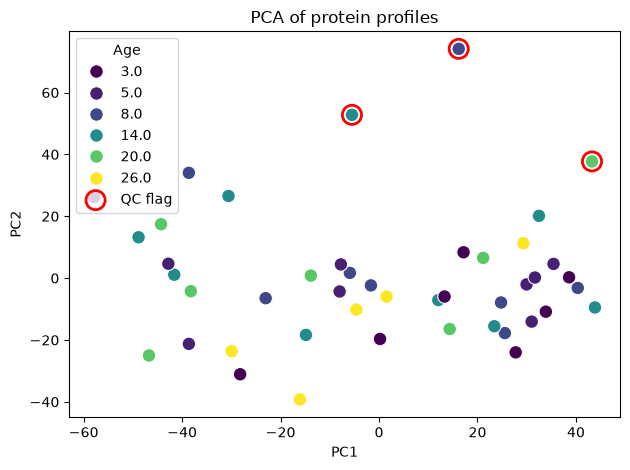

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

meta_aligned = meta.loc[X.index].copy()

# Standardize protein across samples
X_scaled = StandardScaler().fit_transform(X.to_numpy())

pca = PCA(n_components=2)
pc_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    {
        "PC1": pc_scores[:, 0],
        "PC2": pc_scores[:, 1],
        "age": meta_aligned["age"].astype(float).values,
        "sample": X.index,
    }
)

pca_df["qc_flag"] = pca_df["sample"].isin(flagged_samples)

plt.figure()

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="age",
    palette="viridis",
    s=95,
)

# Red outline around flagged samples
plt.scatter(
    pca_df.loc[pca_df["qc_flag"], "PC1"],
    pca_df.loc[pca_df["qc_flag"], "PC2"],
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    s=190,
    label="QC flag",
)

plt.title("PCA of protein profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Age")
plt.tight_layout()
plt.show()

# QC-flagged samples are separated